In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.tree import DecisionTreeClassifier

### step 1
Changes on the dataset

In [7]:
covid_data = pd.read_csv("./Covid Data.csv")
excluded_columns = ['DATE_DIED', 'INTUBED', 'ICU']
covid_data_cleaned = covid_data.drop(columns=excluded_columns)

missing_value_cols = ['PREGNANT', 'DIABETES', 'COPD', 'ASTHMA', 'INMSUPR',
                      'HIPERTENSION', 'OTHER_DISEASE', 'CARDIOVASCULAR', 'OBESITY', 'RENAL_CHRONIC', 'TOBACCO']
covid_data_cleaned[missing_value_cols] = covid_data_cleaned[missing_value_cols].replace({97: None, 99: None})

covid_data_cleaned.loc[covid_data_cleaned['SEX'] == 2, 'PREGNANT'] = 2
covid_data_cleaned['CLASIFFICATION_FINAL'] = (covid_data_cleaned['CLASIFFICATION_FINAL'] <= 3).astype(int)
categorical_cols = ['PREGNANT', 'DIABETES', 'COPD', 'ASTHMA', 'INMSUPR',
                    'HIPERTENSION', 'OTHER_DISEASE', 'CARDIOVASCULAR', 'OBESITY',
                    'RENAL_CHRONIC', 'TOBACCO']
covid_data_cleaned[categorical_cols] = covid_data_cleaned[categorical_cols].apply(pd.to_numeric, errors='coerce')
covid_data_cleaned = covid_data_cleaned.dropna(subset=['CLASIFFICATION_FINAL'])

X = covid_data_cleaned.drop(columns=['CLASIFFICATION_FINAL']).to_numpy()
y = covid_data_cleaned['CLASIFFICATION_FINAL'].to_numpy()

### step 2
Calculate the F1_score without sklearn

In [8]:
def train_test_split_manual(X, y, test_size=0.2, random_seed=42):
    np.random.seed(random_seed)
    indices = np.arange(X.shape[0])
    np.random.shuffle(indices)
    test_count = int(len(indices) * test_size)
    train_indices, test_indices = indices[:-test_count], indices[-test_count:]
    return X[train_indices], X[test_indices], y[train_indices], y[test_indices]

X_train, X_test, y_train, y_test = train_test_split_manual(X, y, test_size=0.2)

def gini_impurity_node(y):
    classes, counts = np.unique(y, return_counts=True)
    prob = counts / counts.sum()
    return 1 - np.sum(prob ** 2)

def gini_gain(y, y_left, y_right):
    parent_impurity = gini_impurity_node(y)
    n = len(y)
    left_impurity = gini_impurity_node(y_left)
    right_impurity = gini_impurity_node(y_right)
    n_left, n_right = len(y_left), len(y_right)
    weighted_impurity = (n_left / n)* left_impurity + (n_right / n)* right_impurity
    return parent_impurity - weighted_impurity

def split(X, y, feature_index, threshold):
    left = X[:, feature_index] <= threshold
    right = X[:, feature_index] > threshold
    return X[left], y[left], X[right], y[right]

class Node:
    def __init__(self, gini, num_samples, num_samples_per_class, predicted_class):
        self.gini = gini
        self.num_samples = num_samples
        self.num_samples_per_class = num_samples_per_class
        self.predicted_class = predicted_class
        self.feature_index = 0
        self.threshold = 0
        self.left = None
        self.right = None
        self.leaf = True

class DecisionTree:
    def __init__(self, max_depth=None):
        self.max_depth = max_depth  

    def fit(self, X, y):
        self.n_classes = len(np.unique(y))
        self.tree = self.build_tree(X, y)

    def build_tree(self, X, y, depth=0):
        num_samples_per_class = [np.sum(y == i) for i in range(self.n_classes)]
        predicted_class = np.argmax(num_samples_per_class)
        node = Node(
            gini=gini_impurity_node(y),
            num_samples=len(y),
            num_samples_per_class=num_samples_per_class,
            predicted_class=predicted_class,
        )

        if (self.max_depth is not None and depth >= self.max_depth) or len(set(y)) == 1:
            return node  

        best_gini_gain = 0
        best_index, best_threshold = None, None
        for feature_index in range(X.shape[1]):
            thresholds = np.unique(X[:, feature_index])
            for threshold in thresholds:
                X_left, y_left, X_right, y_right = split(X, y, feature_index, threshold)
                if len(y_left) > 0 and len(y_right) > 0:
                    gain = gini_gain(y, y_left, y_right)
                    if gain > best_gini_gain:
                        best_gini_gain = gain
                        best_index = feature_index
                        best_threshold = threshold

        if best_gini_gain > 0:
            node.feature_index = best_index
            node.threshold = best_threshold
            X_left, y_left, X_right, y_right = split(X, y, best_index, best_threshold)
            node.leaf = False
            node.left = self.build_tree(X_left, y_left, depth + 1)
            node.right = self.build_tree(X_right, y_right, depth + 1)

        return node

    def predict(self, X):
        return [self.predict_single_input(inputs) for inputs in X]

    def predict_single_input(self, inputs):
        node = self.tree
        while not node.leaf:
            if inputs[node.feature_index] <= node.threshold:
                node = node.left
            else:
                node = node.right
        return node.predicted_class


def calculate_f1_score_per_class(y_true, y_pred):
    unique_classes = np.unique(y_true)
    f1_scores = {}
    
    for class_label in unique_classes:
        tp = np.sum((y_true == class_label) & (y_pred == class_label))
        fp = np.sum((y_true != class_label) & (y_pred == class_label))
        fn = np.sum((y_true == class_label) & (y_pred != class_label))
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        f1_scores[class_label] = f1
    
    return f1_scores

def calculate_f1_macro(y_true, y_pred):
    f1_scores = calculate_f1_score_per_class(y_true, y_pred)
    macro_f1 = np.mean(list(f1_scores.values()))
    return macro_f1


tree = DecisionTree(max_depth=5)
tree.fit(X_train, y_train)
y_pred_custom = tree.predict(X_test)

f1_custom = calculate_f1_macro(y_test, y_pred_custom)
print("F1 Score (Custom Decision Tree):", round(f1_custom, 3))


F1 Score (Custom Decision Tree): 0.577


### step 3
Calculate the F1_score with sklearn

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

classfy = DecisionTreeClassifier(max_depth=5, random_state=42)
classfy.fit(X_train, y_train)
y_pred = classfy.predict(X_test)
print(classification_report(y_test, y_pred, digits=3))
#macro avg is the result of F1_score in the code above

              precision    recall  f1-score   support

           0      0.675     0.893     0.769    131319
           1      0.610     0.280     0.384     78396

    accuracy                          0.664    209715
   macro avg      0.643     0.587     0.576    209715
weighted avg      0.651     0.664     0.625    209715



### Plot for this dicision tree

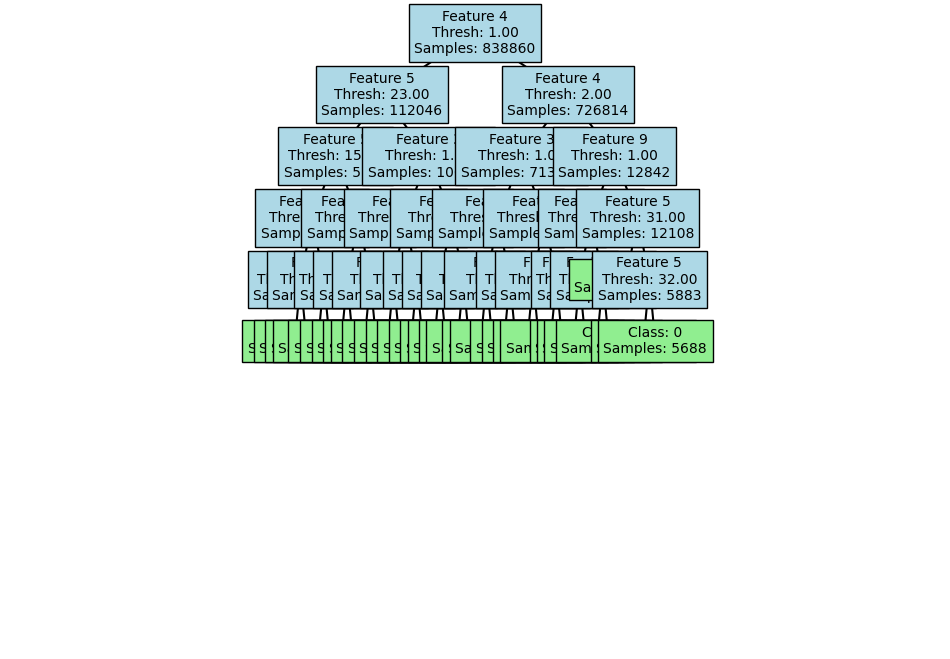

In [10]:
def plot_tree(node, depth=0, x=0.5, y=1.0, dx=0.1, dy=0.1, ax=None):
    """
    Recursively plot the tree.
    
    Parameters:
    - node: Current node of the tree.
    - depth: Depth of the current node.
    - x, y: Current node position.
    - dx: Horizontal distance between child nodes.
    - dy: Vertical distance between levels.
    - ax: Matplotlib Axes object.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 8))
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.axis("off")

    if node.leaf:
        ax.text(x, y, f"Class: {node.predicted_class}\nSamples: {node.num_samples}", 
                ha="center", va="center", bbox=dict(facecolor="lightgreen", edgecolor="black"), fontsize=10)
    else:
        ax.text(x, y, f"Feature {node.feature_index}\nThresh: {node.threshold:.2f}\nSamples: {node.num_samples}", 
                ha="center", va="center", bbox=dict(facecolor="lightblue", edgecolor="black"), fontsize=10)
        if node.left:
            ax.plot([x, x - dx], [y, y - dy], color="black")
            plot_tree(node.left, depth + 1, x - dx, y - dy, dx / 2, dy, ax)
        if node.right:
            ax.plot([x, x + dx], [y, y - dy], color="black")
            plot_tree(node.right, depth + 1, x + dx, y - dy, dx / 2, dy, ax)
    return ax

ax = plot_tree(tree.tree)
plt.show()